High School Completion (%) vs Drug Offences

Correlation is not Statistically Signifigant!!!
Pearson Correlation Coefficient: -0.21
P-value: 0.273


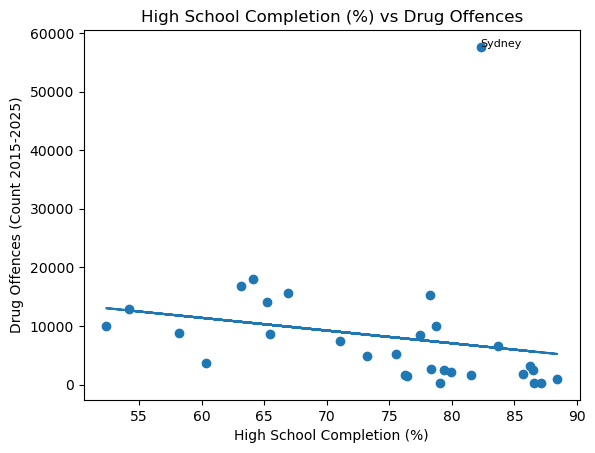




High School Completion (%) vs Violent Crime

Pearson Correlation Coefficient: -0.54
P-value: 0.002


<Figure size 640x480 with 0 Axes>

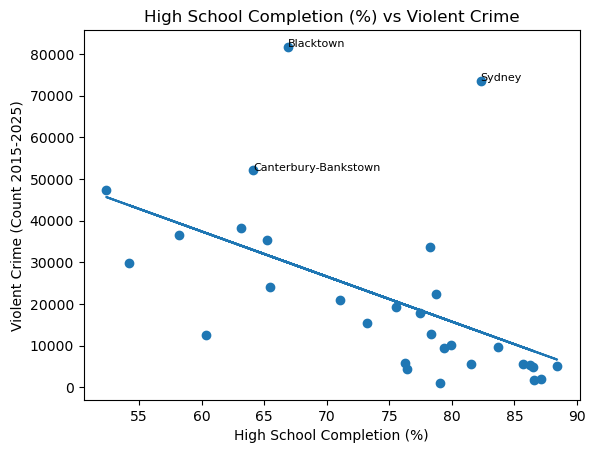




High School Completion (%) vs Property Offences

Pearson Correlation Coefficient: -0.47
P-value: 0.008


<Figure size 640x480 with 0 Axes>

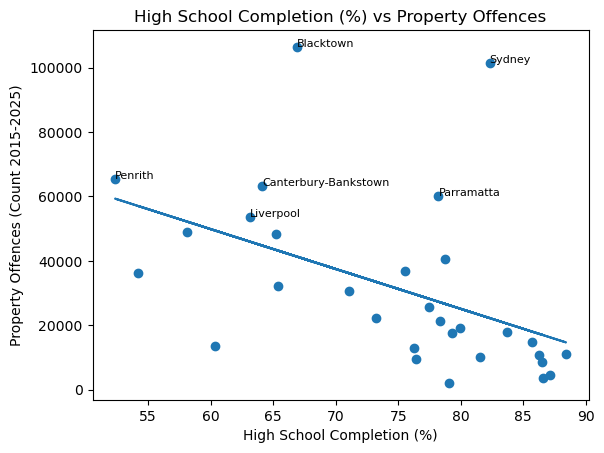




Unemployment (%) vs Drug Offences

Pearson Correlation Coefficient: 0.36
P-value: 0.049


<Figure size 640x480 with 0 Axes>

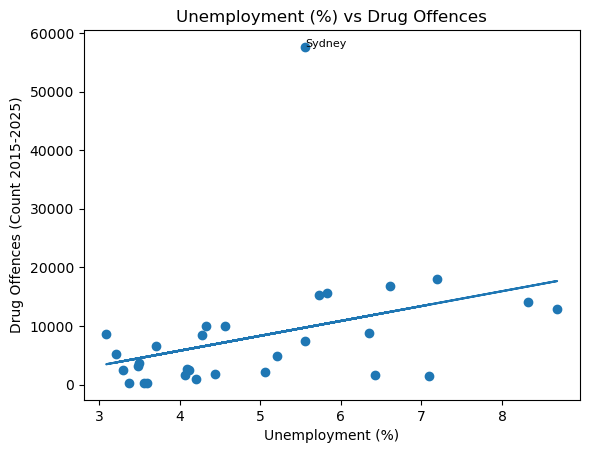




Unemployment (%) vs Violent Crime

Pearson Correlation Coefficient: 0.46
P-value: 0.010


<Figure size 640x480 with 0 Axes>

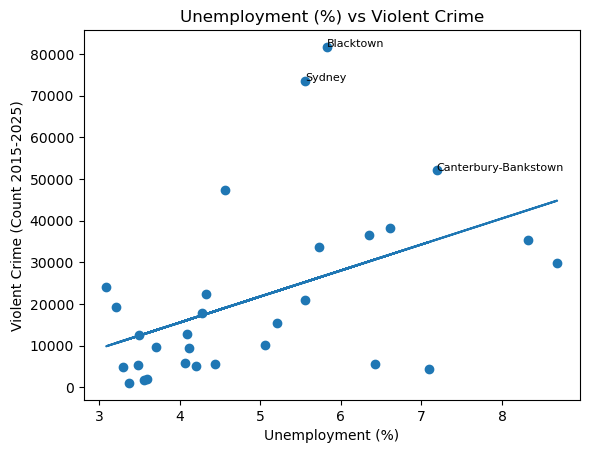




Unemployment (%) vs Property Offences

Pearson Correlation Coefficient: 0.43
P-value: 0.017


<Figure size 640x480 with 0 Axes>

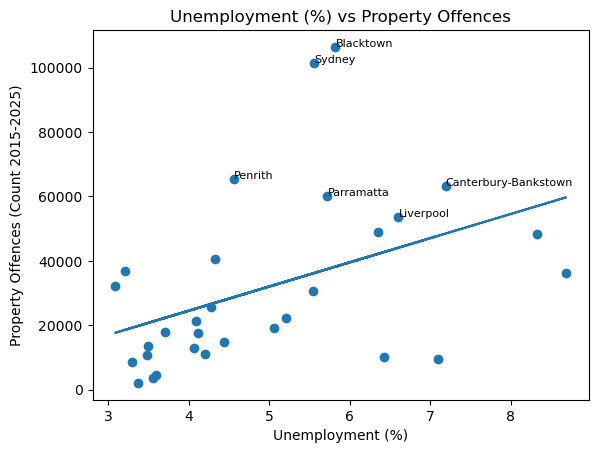




Median Weekly Income ($) vs Drug Offences

Pearson Correlation Coefficient: -0.37
P-value: 0.043


<Figure size 640x480 with 0 Axes>

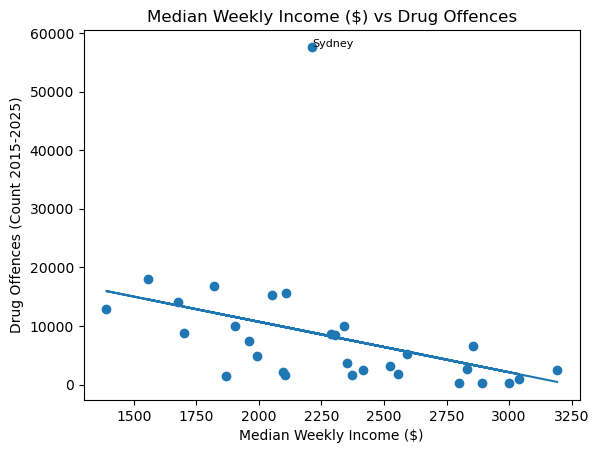




Median Weekly Income ($) vs Violent Crime

Pearson Correlation Coefficient: -0.55
P-value: 0.002


<Figure size 640x480 with 0 Axes>

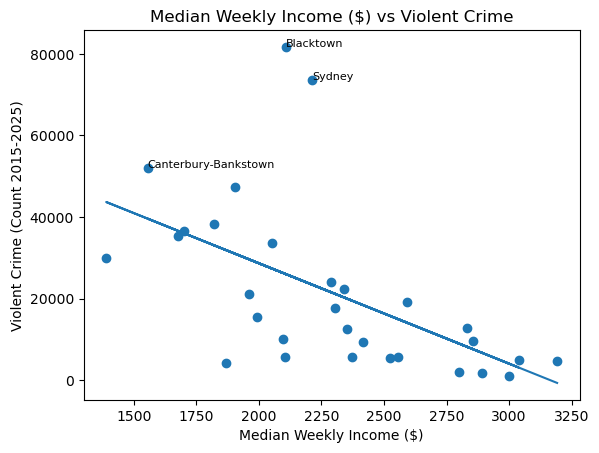




Median Weekly Income ($) vs Property Offences

Pearson Correlation Coefficient: -0.52
P-value: 0.003


<Figure size 640x480 with 0 Axes>

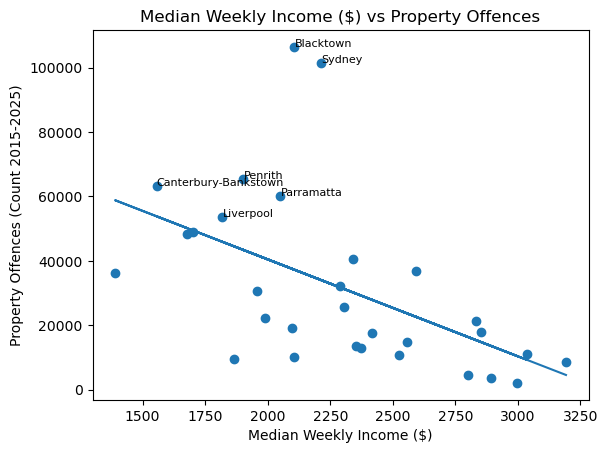




High School Completion (%) vs Drug Offences (Sydney Removed)

Pearson Correlation Coefficient: -0.65
P-value: 0.000


<Figure size 640x480 with 0 Axes>

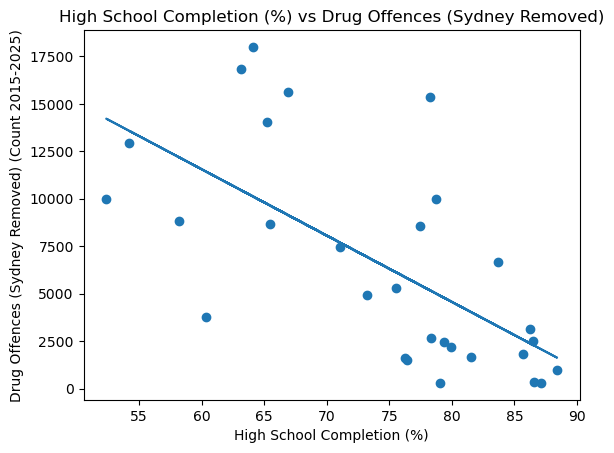




Unemployment (%) vs Drug Offences (Sydney Removed)

Pearson Correlation Coefficient: 0.59
P-value: 0.001


<Figure size 640x480 with 0 Axes>

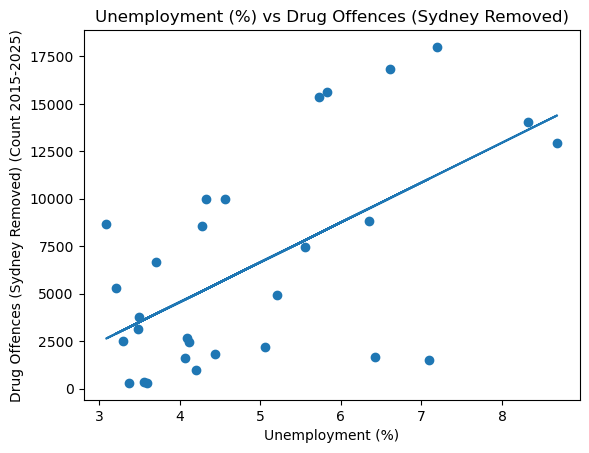




Median Weekly Income ($) vs Drug Offences (Sydney Removed)

Pearson Correlation Coefficient: -0.68
P-value: 0.000


<Figure size 640x480 with 0 Axes>

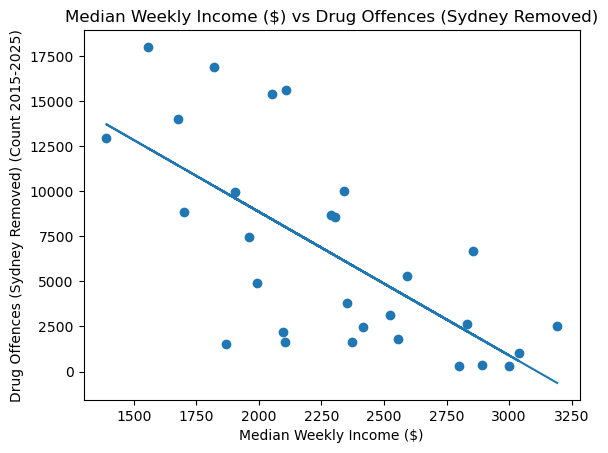

<Figure size 640x480 with 0 Axes>

In [ ]:
"""
THE WILD WEST
"""

import numpy as np
from scipy import stats
import geopandas as gpd
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plot

path = Path("/Users/tarapowell/Desktop/GIS AT3") #MOLLY YOU WILL NEED TO ADD YOUR OWN PATH IN


def correlation(x,y):
    pearson = stats.pearsonr(x, y)
    
    p = pearson.pvalue
    r = pearson.statistic
    
    if p > 0.05:
        print("Correlation is not Statistically Signifigant!!!")
    
    print(f"Pearson Correlation Coefficient: {r:.2f}")
    print(f"P-value: {p:.3f}")
    
    #return p, r


def printscatter(x,y,xhead,yhead,pointlabels):
    #https://www.statology.org/line-of-best-fit-python/
    m, c = np.polyfit(x, y, 1)

    plot.figure()
    plot.title(f"{xhead} vs {yhead}")
    plot.xlabel(f"{xhead}")
    plot.ylabel(f"{yhead} (Count 2015-2025)")
    plot.scatter(x, y)
    plot.plot(x, m*x+c)
    
    for i, label in enumerate(pointlabels):
        if y[i] > 50000:
            plot.text(x[i],y[i],label,fontsize=8)
        
    plot.show()
    plot.clf()


def main():
    #https://medium.com/data-science/how-to-convert-a-shapefile-to-a-dataframe-in-python-a6ca9a893504
    inputfile = path / "SydneyLGAs_MGA202056_socioecon_crime_2015_2025.shp"
    dataframe = gpd.read_file(inputfile)
    
    pointlabels = dataframe["LGA_NAME25"]
    
    xschool = dataframe["High_Schoo"].to_numpy() #PERCENTAGE High School Completion 
    xunemploy = dataframe["Unemployme"].to_numpy() #PERCENTAGE Unemployment
    xincome = dataframe["Median_tot"].to_numpy() #Median Weekly Income
    
    xlist = [xschool, xunemploy, xincome]
    xheadings = ["High School Completion (%)", "Unemployment (%)", "Median Weekly Income ($)"]
    
    ydrugs = dataframe["Drugs_Tota"].to_numpy()
    yVC = dataframe["VC_Total"].to_numpy()
    yPO = dataframe["PO_Total"].to_numpy()
    
    ylist = [ydrugs, yVC, yPO]
    yheadings = ["Drug Offences", "Violent Crime", "Property Offences"]
    
    #Correlation between total counts and socioeconomic factors. 
    for x, xhead in zip(xlist,xheadings):
        for y, yhead in zip(ylist, yheadings):
            print(f"{xhead} vs {yhead}\n")
            correlation(x,y)
            printscatter(x,y,xhead,yhead,pointlabels)
            print("\n\n")
            
    #Drug offences has a huge outlier in the Sydney CBD so it will be removed
    dataframe_nosyd = dataframe.copy()
    dataframe_nosyd = dataframe_nosyd.drop(dataframe_nosyd[dataframe_nosyd["LGA_NAME25"] == "Sydney"].index)
    
    pointlabels_nosyd = dataframe_nosyd["LGA_NAME25"]
    ydrugs_nosyd = dataframe_nosyd["Drugs_Tota"].to_numpy()
    
    xschool_nosyd = dataframe_nosyd["High_Schoo"].to_numpy() #PERCENTAGE High School Completion 
    xunemploy_nosyd = dataframe_nosyd["Unemployme"].to_numpy() #PERCENTAGE Unemployment
    xincome_nosyd = dataframe_nosyd["Median_tot"].to_numpy() #Median Weekly Income
    
    xlist_nosyd = [xschool_nosyd, xunemploy_nosyd, xincome_nosyd]
    
    for x, xhead in zip(xlist_nosyd,xheadings):
        print(f"{xhead} vs Drug Offences (Sydney Removed)\n")
        correlation(x,ydrugs_nosyd)
        printscatter(x,ydrugs_nosyd,xhead, "Drug Offences (Sydney Removed)", pointlabels_nosyd)
        print("\n\n")


if __name__ == "__main__":
    main()
